In [1]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

In [2]:
# Cosntants: WACO CG-4A
# Air Constants
g = 9.81
RHO = 1.225

# Aircraft Param
m = 3402.0
S = 83.6

# Aerodynamic Coefficients
CD0 = 0.033
k = 0.055
CL_min = 0.10
CL_max = 1.70

# Structural Limit
n_max = 3.5

# State bounds
v_min = 19.6            # Stall speed
v_max = 67.0
gamma_min = 0.0
gamma_max = np.deg2rad(90.0)

In [3]:
# Intermediate Functions
def compute_CD(CL):
    return CD0 + k * CL**2

def compute_lift(v, CL):
    return 0.5 * RHO * v**2 * S * CL

def compute_drag(v, CL):
    CD = compute_CD(CL)
    return 0.5 * RHO * v**2 * S * CD

def compute_stall_speed(gamma):
    return np.sqrt((2 * m * g * np.cos(gamma)) / (RHO * S * CL_max))

def compute_LD(CL):
    CD = compute_CD(CL)
    return CL / CD

def dynamics_eq(x, u):
    z, h, v, gamma = x
    CL = u

    L = compute_lift(v, CL)
    D=  compute_drag(v, CL)

    zdot = v*np.cos(gamma)
    hdot = -v*np.sin(gamma)
    vdot = g*np.sin(gamma) - D/m
    gammadot = g*np.cos(gamma)/v - L/(m*v)

    return np.array([zdot, hdot, vdot, gammadot])

def dynamics_eq_backward(x, u):
    return -dynamics_eq(x, u)

def is_feasible(x, u):
    z, h, v, gamma = x
    CL = u

    stall_ok =  v > compute_stall_speed(gamma)
    gamma_ok = (gamma >= gamma_min) and (gamma <= gamma_max)
    control_ok = (CL >= CL_min) and (CL <= CL_max)
    load_ok = compute_lift(v, CL) / m <= n_max * g

    return stall_ok and gamma_ok and control_ok and load_ok

In [16]:
# Simulation for Fixed Control input
# CL fixed
def dynamics_eq_casadi(x, u):
    z = x[0]
    h = x[1]
    v = x[2]
    gamma = x[3]

    CL = u

    CD = CD0 + k * CL**2
    L = 0.5 * RHO * v**2 * S * CL
    D = 0.5 * RHO * v**2 * S * CD

    zdot = v*ca.cos(gamma)
    hdot = -v*ca.sin(gamma)
    vdot = g*ca.sin(gamma) - D/m
    gammadot = g*ca.cos(gamma)/v - L/(m*v)

    return ca.vertcat(zdot, hdot, vdot, gammadot)

def dynamics_eq_casadi_backward(x, u):
    return -dynamics_eq_casadi(x, u)

In [5]:
# Fixed CL Simulation
# Time Parameters
dt = 0.1
T = 500.0
N = int(T/dt)

# Initial state at switching point
z_sw = 0.0
h_sw = 750.0
v_sw = 32.2               # Nominal glide speed
gamma_sw = np.deg2rad(10.0)

x0 = np.array([z_sw, h_sw, v_sw, gamma_sw])

# Fixed control input (CL)
CL_fixed = 0.77         # Best L/D condition for CG-4A

In [6]:
# Casadi Integration
x_sym = ca.MX.sym('x', 4)
u_sym = ca.MX.sym('u', 1)

# ODE definition
ode = {'x': x_sym, 'p': u_sym, 'ode': dynamics_eq_casadi(x_sym, u_sym)}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', ode, opts)

# Simulate
x_hist = np.zeros((N+1, 4))
x_hist[0] = x0
x_current = x0

for i in range(N):
    # STop if we hit the ground
    if x_current[1] <= 0:
        print(f"Hit the ground at time {i*dt:.2f} seconds")
        x_hist = x_hist[:i+1]
        break

    res = integrator(x0=x_current, p=[CL_fixed])
    x_current = np.array(res['xf']).flatten()
    x_hist[i+1] = x_current

CasADi - 2026-04-28 22:38:41 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated.
The same functionality is provided by providing additional input arguments to the 'integrator' function, in particular:
 * Call integrator(..., t0, tf, options) for a single output time, or
 * Call integrator(..., t0, grid, options) for multiple grid points.
The legacy 'output_t0' option can be emulated by including or excluding 't0' in 'grid'.
Backwards compatibility is provided in this release only.") [.../casadi/core/integrator.cpp:692]


Hit the ground at time 307.50 seconds


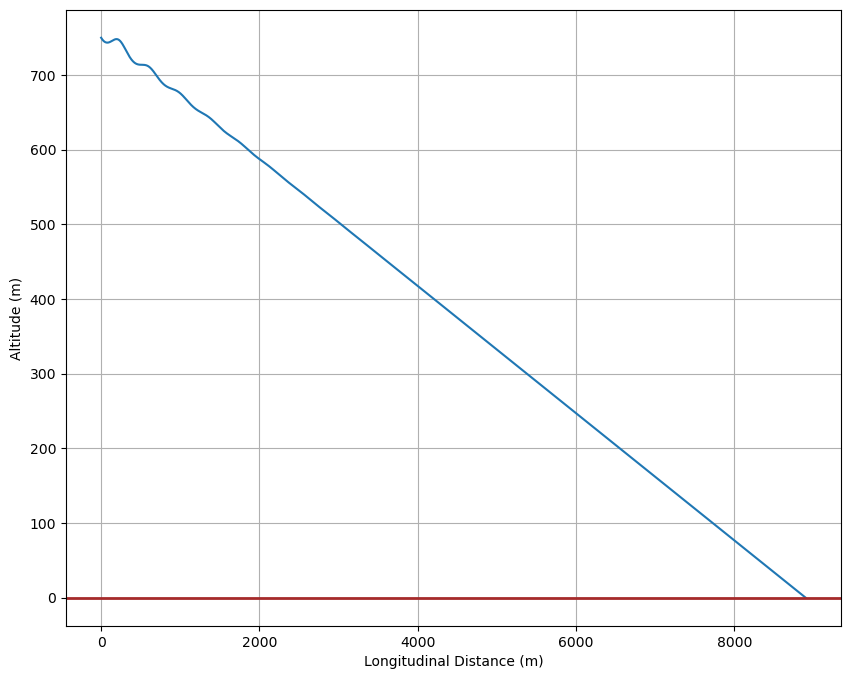

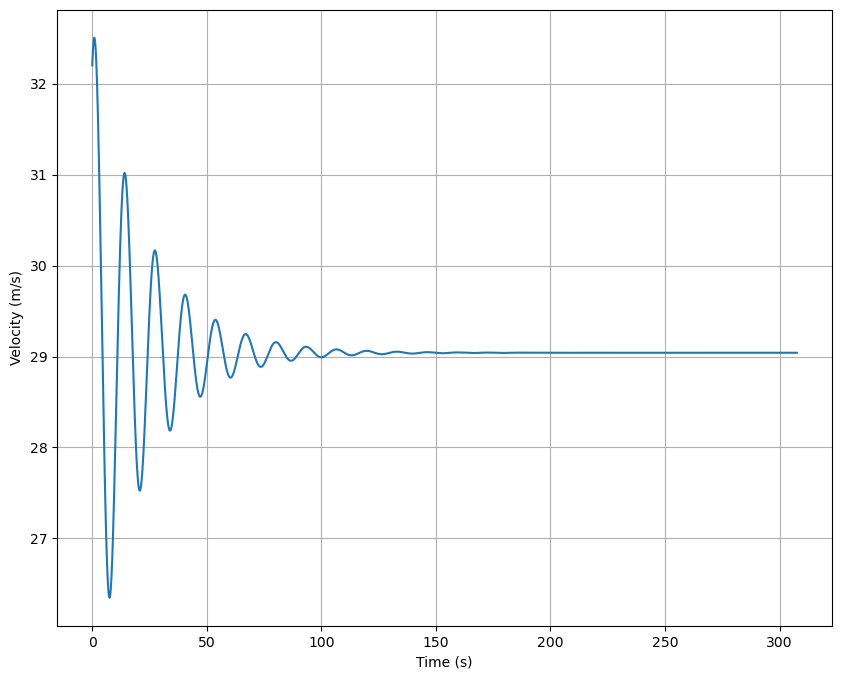

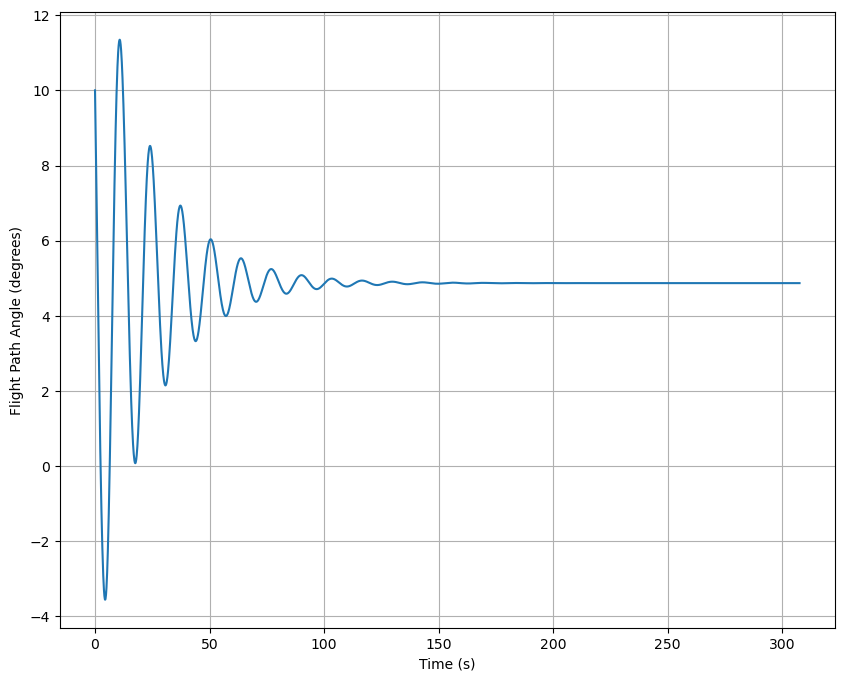

In [7]:
# Fixed CL Plot
t_hist = np.arange(len(x_hist)) * dt

fig1, ax1 = plt.subplots(figsize=(10, 8))
ax1.plot(x_hist[:, 0], x_hist[:, 1])
ax1.axhline(0, color='brown', linewidth=2, label='Ground')
ax1.set_xlabel('Longitudinal Distance (m)')
ax1.set_ylabel('Altitude (m)')
ax1.grid(True)

fig2, ax2 = plt.subplots(figsize=(10, 8))
ax2.plot(t_hist, x_hist[:, 2])
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Velocity (m/s)')
ax2.grid(True)

fig3, ax3 = plt.subplots(figsize=(10, 8))
ax3.plot(t_hist, np.rad2deg(x_hist[:, 3]))
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Flight Path Angle (degrees)')
ax3.grid(True)

In [8]:
# Forward Reachability Analysis
N_z = 100
N_h = 100
z_goal = 6000.0
h_goal = 0.0
z_grid = np.linspace(z_sw, z_goal, N_z)
h_grid = np.linspace(h_goal, h_sw, N_h)

# Reachable map[i, j = 1 if cell is reachable, else 0]
reachable_map = np.zeros((N_z, N_h), dtype=bool)

In [9]:
# Control discretization
N_CL = 20
CL_samples = np.linspace(CL_min, CL_max, N_CL)

def get_grid_index(z, h):
    iz = int((z - z_sw) / (z_goal - z_sw) * (N_z - 1))
    ih = int((h - h_goal) / (h_sw - h_goal) * (N_h - 1))

    if iz < 0 or iz >= N_z:
        return None
    if ih < 0 or ih >= N_h:
        return None
    return iz, ih

In [10]:
# Grid Setup
N_z = 100
N_h = 100
z_grid = np.linspace(z_sw, z_goal, N_z)
h_grid = np.linspace(h_goal, h_sw, N_h)

reachable_map = np.zeros((N_z, N_h), dtype=bool)

def get_grid_index(z, h):
    iz = int((z - z_sw) / (z_goal - z_sw) * (N_z - 1))
    ih = int((h - h_goal) / (h_sw - h_goal) * (N_h - 1))

    if iz < 0 or iz >= N_z:
        return None
    if ih < 0 or ih >= N_h:
        return None
    return iz, ih

# Casadi Integrator
x_sym = ca.MX.sym('x', 4)
u_sym = ca.MX.sym('u', 1)

dt = 10.0

ode = {'x': x_sym, 'p': u_sym, 'ode': dynamics_eq_casadi(x_sym, u_sym)}
opts = {'tf': dt}
integrator = ca.integrator('integrator', 'rk', ode, opts)

# Forward Reachability
# Initiate State at Start with steady_state values
v_sw = 29.1
gamma_sw = np.deg2rad(4.87)
x_sw = np.array([z_sw, h_sw, v_sw, gamma_sw])

CL_norm = (CL_samples - CL_min) / (CL_max - CL_min)
next_points = []
next_colors = []
next_CL = []
infeasible_points = []

active_states = [x_sw]
all_feasible_points = []

# Mark initial cell
idx = get_grid_index(z_sw, h_sw)
if idx:
    reachable_map[idx] = True

active_cells = set()
if idx:
    active_cells.add(idx)


max_iter = 500
for iteration in range(max_iter):
    print(iteration)
    next_states = []
    new_cells = set()

    for x_curr in active_states:
        for i, CL in enumerate(CL_samples):
            res = integrator(x0=x_curr, p=[CL])
            x_next = np.array(res['xf']).flatten()
            z_next, h_next, v_next, gamma_next = x_next

            feasible = is_feasible(x_next, CL)
            if feasible:
                # next_points.append(x_next)
                # color = (0.0, 0.0, 1.0 - 0.9*CL_norm[i])
                # next_colors.append(color)
                # next_CL.append(CL)
                # all_feasible_points.append((z_next, h_next))
                # next_states.append(x_next)

                idx = get_grid_index(z_next, h_next)
                if idx is None:
                    continue
                    
                # Keep only if this cell has not been visited before
                if idx not in active_cells:
                    active_cells.add(idx)
                    new_cells.add(idx)
                    reachable_map[idx] = True
                    all_feasible_points.append((z_next, h_next))
                    next_states.append(x_next)

            else:
                infeasible_points.append((z_next, h_next))
    active_states = next_states


0
1
2
3


/tmp/ipykernel_546874/4291905659.py:13: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((2 * m * g * np.cos(gamma)) / (RHO * S * CL_max))


4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
27

In [11]:
print(len(all_feasible_points))
print(len(infeasible_points))

4612
38915


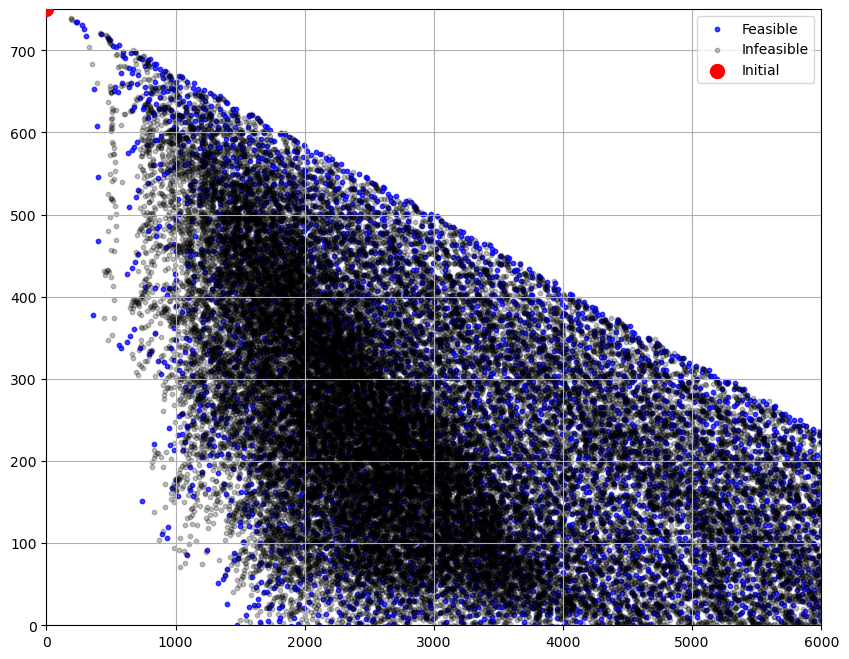

In [12]:
next_points = np.array(next_points)
infeasible_points = np.array(infeasible_points)

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(all_feasible_points)):
    ax.scatter(all_feasible_points[i][0], all_feasible_points[i][1], color='blue', s=10, label=('Feasible' if i == 0 else None), alpha=0.75)
if len(infeasible_points) > 0:
    ax.scatter(infeasible_points[:, 0], infeasible_points[:, 1], color='black', s=10, label=('Infeasible' if len(infeasible_points) > 0 else None), alpha=0.25)
# for i in range(max_iter):
#     ax.plot([x0[0], next_points[0, 0]], [x0[1], next_points[0, 1]], color=next_colors[0], linestyle='--')
#     ax.plot([x0[0], next_points[-1, 0]], [x0[1], next_points[-1, 1]], color=next_colors[-1], linestyle='--')
ax.scatter(x0[0], x0[1], color='red', s=100, label='Initial', zorder=100)
ax.set_xlim(0, z_goal)
ax.set_ylim(0, h_sw)
ax.grid(True)
ax.legend()

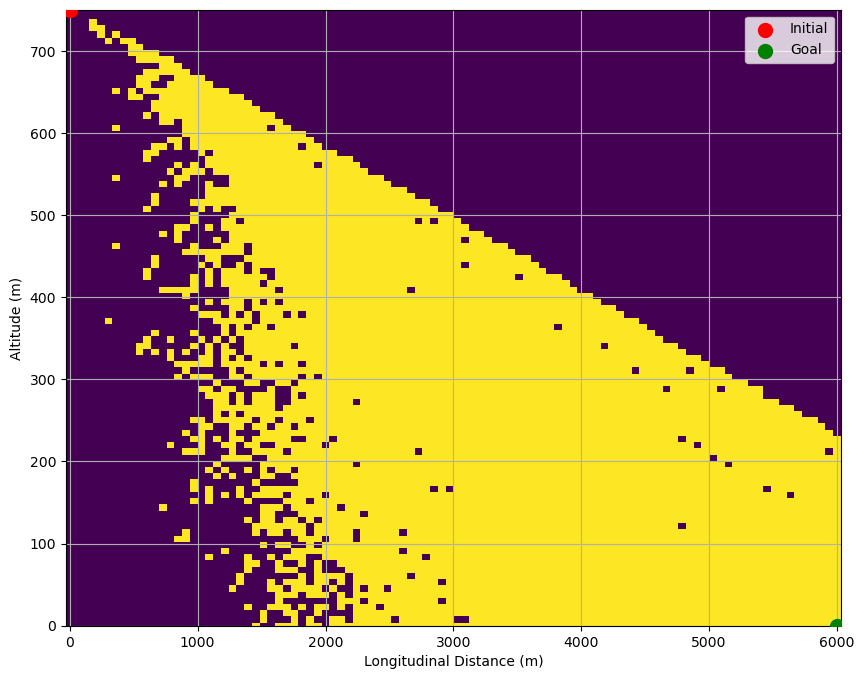

In [13]:
# Heatmap
Z_plot, H_plot = np.meshgrid(z_grid, h_grid)

# Reachable map transpose
map_plot = reachable_map.T
plt.close('all')

# Heatmap plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.pcolormesh(Z_plot, H_plot, map_plot, shading='auto')
ax.scatter(z_sw, h_sw, color='red', s=100, label='Initial', zorder=100)
ax.scatter(z_goal, h_goal, color='green', s=100, label='Goal', zorder=100)
ax.set_xlabel('Longitudinal Distance (m)')
ax.set_ylabel('Altitude (m)')
ax.set_ylim(0, h_sw)
ax.legend()
ax.grid(True)